<a href="https://colab.research.google.com/github/marynjihia/Flood-prediction-using-environmental-and-population-dataset/blob/main/Main_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("naiyakhalid/flood-prediction-dataset")
df = pd.read_csv(path + "/flood.csv")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flood-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/flood-prediction-dataset


In [ ]:
# https://www.kaggle.com/code/sudhirsingh108/population-dataset-analysis?scriptVersionId=134285344&cellId=2

In [ ]:
import pandas as pd

flood_df = pd.read_csv(path + "/flood.csv")

# Download and load the population dataset
population_path = kagglehub.dataset_download("iamsouravbanerjee/world-population-dataset")
population_df = pd.read_csv(population_path + "/world_population.csv")
print("Path to population dataset files:", population_path)

100%|██████████| 15.7k/15.7k [00:00<00:00, 15.5MB/s]

Extracting files...
Path to population dataset files: /root/.cache/kagglehub/datasets/iamsouravbanerjee/world-population-dataset/versions/4


In [ ]:
# 🔗 Direct download: kaggle.com/datasets/iamsouravbanerjee/world-population-dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 🔗 Direct download: kaggle.com/datasets/s3programmer/flood-risk-in-india

In [ ]:
flood_df.shape

(50000, 21)

In [ ]:
flood_df.head()
# population_df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [ ]:
## clean column names

In [ ]:
flood_df.columns = flood_df.columns.str.strip()
population_df.columns = population_df.columns.str.strip()

## merge datasets

In [ ]:
# merged_df = pd.merge(flood_df, population_df, on='country', how='inner')
# print("merged shape:", merged_df.shape)
# merged_df.head
# Placeholder to avoid error due to merged_df not existing after commenting out merge
print("Flood DataFrame columns:", flood_df.columns.tolist())
print("Population DataFrame columns:", population_df.columns.tolist())

Flood DataFrame columns: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']
Population DataFrame columns: ['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022 Population', '2020 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']


In [ ]:
flood_df.head()
population_df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


##Data understanding

In [ ]:
flood_df.info()
flood_df.describe()
flood_df.isnull()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# drop missing values
flood_df = flood_df.dropna()
# fill missing values
flood_df.fillna(flood_df.mean(), inplace=True)

In [ ]:
flood_df()

EDA

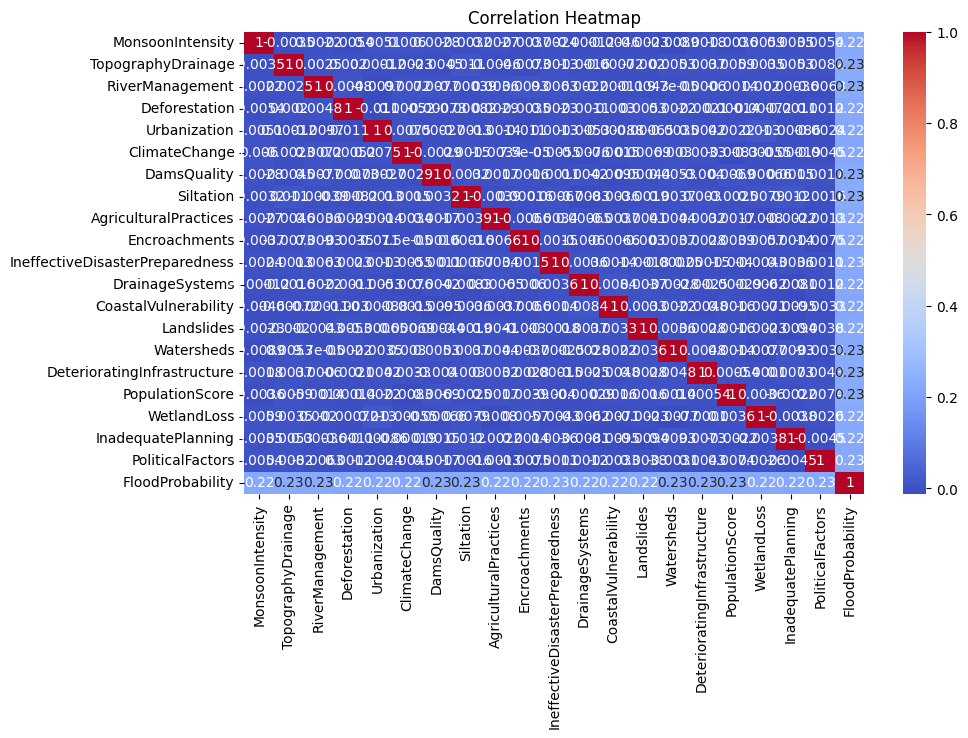

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(flood_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## distribution of target variable

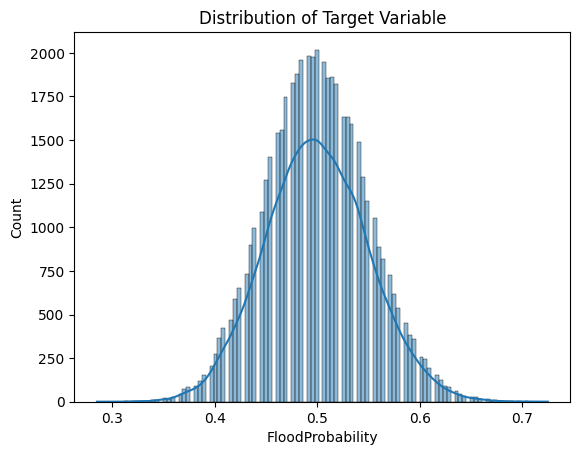

In [ ]:
sns.histplot(x='FloodProbability', data=flood_df, kde=True)
plt.title('Distribution of Target Variable')
plt.show()

## handling missing values

In [ ]:
# info
flood_df.info()

#check missing values
flood_df.isnull().sum()

#describe data
flood_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


In [ ]:
#filling missing values
flood_df.fillna(flood_df.mean(), inplace=True)

##drop duplicates
flood_df.drop_duplicates(inplace=True)

In [ ]:
population_df.info()
population_df.isnull().sum()
population_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   country                      234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
count,234.000000,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,234.000000,234.000000,234.000000
mean,117.500000,3.407441e+07,3.350107e+07,3.172996e+07,2.984524e+07,2.626947e+07,2.271022e+07,1.898462e+07,1.578691e+07,5.814494e+05,452.127044,1.009577,0.427051
std,67.694165,1.367664e+08,1.355899e+08,1.304050e+08,1.242185e+08,1.116982e+08,9.783217e+07,8.178519e+07,6.779509e+07,1.761841e+06,2066.121904,0.013385,1.714977
min,1.000000,5.100000e+02,5.200000e+02,5.640000e+02,5.960000e+02,6.510000e+02,7.000000e+02,7.330000e+02,7.520000e+02,1.000000e+00,0.026100,0.912000,0.000000
25%,59.250000,4.197385e+05,4.152845e+05,4.046760e+05,3.931490e+05,3.272420e+05,2.641158e+05,2.296142e+05,1.559970e+05,2.650000e+03,38.417875,1.001775,0.010000
50%,117.500000,5.559944e+06,5.493074e+06,5.307400e+06,4.942770e+06,4.292907e+06,3.825410e+06,3.141146e+06,2.604830e+06,8.119950e+04,95.346750,1.007900,0.070000
75%,175.750000,2.247650e+07,2.144798e+07,1.973085e+07,1.915957e+07,1.576230e+07,1.186923e+07,9.826054e+06,8.817329e+06,4.304258e+05,238.933250,1.016950,0.280000
max,234.000000,1.425887e+09,1.424930e+09,1.393715e+09,1.348191e+09,1.264099e+09,1.153704e+09,9.823725e+08,8.225344e+08,1.709824e+07,23172.266700,1.069100,17.880000


In [ ]:
population_df.rename(columns={'Country/Territory': 'country'}, inplace=True)

In [ ]:
population_df["country"]= population_df["country"].str.lower()

## outlier detection and treatment


## feature engineering and encoding

### merge datasets

In [ ]:
## before merging
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split



In [ ]:
population_df.rename(columns={'Country/Territory': 'country'}, inplace=True)

merged_data = flood_df
print("Flood DataFrame columns:", flood_df.columns.tolist())
print("Population DataFrame columns (after rename):", population_df.columns.tolist())
merged_data.head()

Flood DataFrame columns: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']
Population DataFrame columns (after rename): ['Rank', 'CCA3', 'country', 'Capital', 'Continent', '2022 Population', '2020 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


##feature selection

In [ ]:
x = merged_data.drop(columns=['FloodProbability'])
y = merged_data['FloodProbability']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
merged_data.to_csv("merged_flood_population.csv", index=False)

## visualization

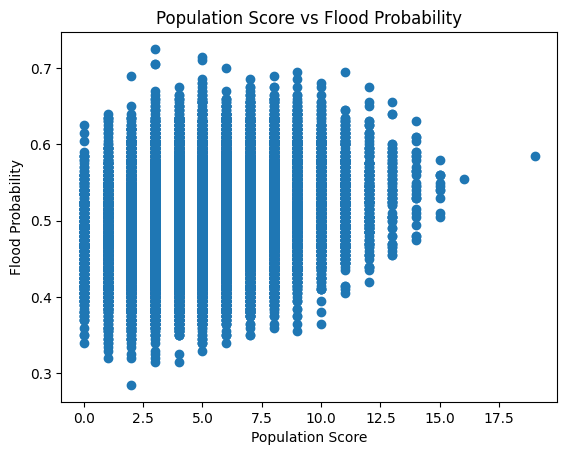

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(merged_data['PopulationScore'], merged_data['FloodProbability'])
plt.xlabel('Population Score')
plt.ylabel('Flood Probability')
plt.title('Population Score vs Flood Probability')
plt.show()

## train,split and test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

x = merged_data.drop(columns=['FloodProbability'])
y = merged_data['FloodProbability']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
# model = RandomForestClassifier()
model.fit(x_train, y_train)

print("accuracy:", model.score(x_test, y_test))

accuracy: 0.7294957103200914


## Evaluation Metrics

## compare the  results

In [ ]:
accuracy_after_merge = 0.7294957103200914
accuracy_before_merge = 0.0

## improvent accuracy
improvement = accuracy_after_merge - accuracy_before_merge
print("Improvement in accuracy:", improvement)
print("\nModel comparison:")
print("Before merge:", accuracy_before_merge)
print("After merge:", accuracy_after_merge)

Improvement in accuracy: 0.7294957103200914

Model comparison:
Before merge: 0.0
After merge: 0.7294957103200914


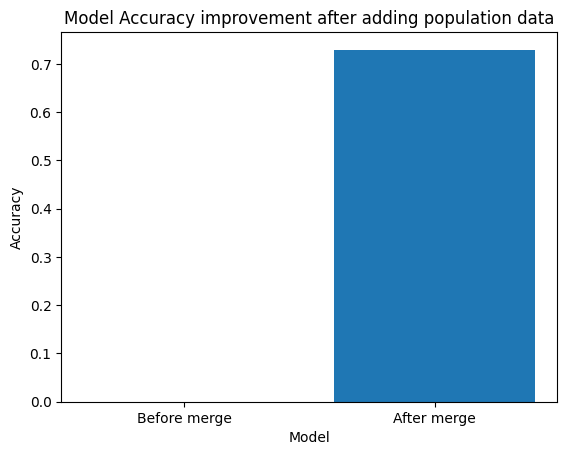

In [ ]:
import matplotlib.pyplot as plt

models = ['Before merge', 'After merge']
accuracies = [accuracy_before_merge, accuracy_after_merge]

plt.bar(models, accuracies)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy improvement after adding population data')
plt.show()

## precision and recall: before merging

In [ ]:
from sklearn.metrics import precision_score, recall_score, classification_report

In [ ]:
# Get continuous predictions from the previously trained RandomForestRegressor
y_pred_continuous = model.predict(x_test)

y_test_binary = (y_test > 0.5).astype(int)
y_pred_binary = (y_pred_continuous > 0.5).astype(int)

# Calculate precision and recall using the binarized labels
precision_before_merge = precision_score(y_true=y_test_binary, y_pred=y_pred_binary, average='binary')
recall_before_merge = recall_score(y_true=y_test_binary, y_pred=y_pred_binary, average='binary')

print("Precision (Before merge):", precision_before_merge)
print("Recall (Before merge):", recall_before_merge)

Precision (Before merge): 0.8855597170203912
Recall (Before merge): 0.8978902953586498


## after merging

In [ ]:

y_pred_continuous_after = model.predict(x_test)


y_test_binary = (y_test > 0.5).astype(int)
y_pred_after_binary = (y_pred_continuous_after > 0.5).astype(int)
precision_after_merge = precision_score(y_true=y_test_binary, y_pred=y_pred_after_binary, average='binary')
recall_after_merge = recall_score(y_true=y_test_binary, y_pred=y_pred_after_binary, average='binary')

print("\nafter merging")
print("Precision (After merge):", precision_after_merge)
print("Recall (After merge):", recall_after_merge)


after merging
Precision (After merge): 0.8855597170203912
Recall (After merge): 0.8978902953586498


In [ ]:
precision_score(y_test_binary, y_pred_after_binary, average='weighted')
recall_score(y_test_binary, y_pred_after_binary, average='weighted')

0.8966

### comparing the improvement

In [ ]:
print("Improvement in precision:", precision_after_merge - precision_before_merge)
print("Improvement in recall:", recall_after_merge - recall_before_merge)

Improvement in precision: 0.0
Improvement in recall: 0.0


### F1 Score

In [ ]:
from sklearn.metrics import f1_score
f1_score_before_merge = f1_score(y_test_binary, y_pred_binary, average='weighted')
f1_score_after_merge = f1_score(y_test_binary, y_pred_after_binary, average='weighted')
print("F1 Score (Before merge):", f1_score_before_merge)
print("F1 Score (After merge):", f1_score_after_merge)

F1 Score (Before merge): 0.896631046768357
F1 Score (After merge): 0.896631046768357


it has achieved an F1 score of o.8966 indicating strong balanced performance between precision and recall.This suggests that the model is reliable in predicting flood events while minimizing both false positive and false negatives

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [ ]:
x = merged_data.drop(columns=['FloodProbability'])
y = merged_data['FloodProbability']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### desicion tree model

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

# Binarize y_train and y_test for classification
y_train_binary = (y_train > 0.5).astype(int)
y_test_binary = (y_test > 0.5).astype(int)

dt_model.fit(x_train, y_train_binary)
dt_predictions = dt_model.predict(x_test)
dt_accuracy = accuracy_score(y_test_binary, dt_predictions)
dt_F1_score = f1_score(y_test_binary, dt_predictions, average='weighted')
print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree F1 Score:", dt_F1_score)

Decision Tree Accuracy: 0.6914
Decision Tree F1 Score: 0.6912961981506296


using logistic regression

In [ ]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(x_train, y_train_binary)
lr_predictions = lr_model.predict(x_test)
lr_accuracy = accuracy_score(y_test_binary, lr_predictions)
lr_F1_score = f1_score(y_test_binary, lr_predictions, average='weighted')
print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression F1 Score:", lr_F1_score)

Logistic Regression Accuracy: 1.0
Logistic Regression F1 Score: 1.0


## using XG boost


In [ ]:
xgboost_model = XGBClassifier(eval_metric='logloss')
xgboost_model.fit(x_train, y_train_binary)
xgboost_predictions = xgboost_model.predict(x_test)
xgboost_accuracy = accuracy_score(y_test_binary, xgboost_predictions)
xgboost_F1_score = f1_score(y_test_binary, xgboost_predictions, average='weighted')
print("XGBoost Accuracy:", xgboost_accuracy)
print("XGBoost F1 Score:", xgboost_F1_score)

XGBoost Accuracy: 0.9327
XGBoost F1 Score: 0.9326876807496235


##comparing all of them

In [ ]:
print("\nModel comparison:")
print("Decision Tree Accuracy:", dt_accuracy)
"F1 Score:", dt_F1_score
print("logistic regression F1 Score:", dt_accuracy)
"F1 Score:", lr_F1_score
print("XGBoost Accuracy:", xgboost_accuracy)
"F1 Score:", xgboost_F1_score


Model comparison:
Decision Tree Accuracy: 0.6914
logistic regression F1 Score: 0.6914
XGBoost Accuracy: 0.9327


('F1 Score:', 0.9326876807496235)

## confusion matrix


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib as plt

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    display.plot(cmap='Blues')
    plt.show()
    plt.figure(figsize=(8, 6))

## random forest confusion matrix

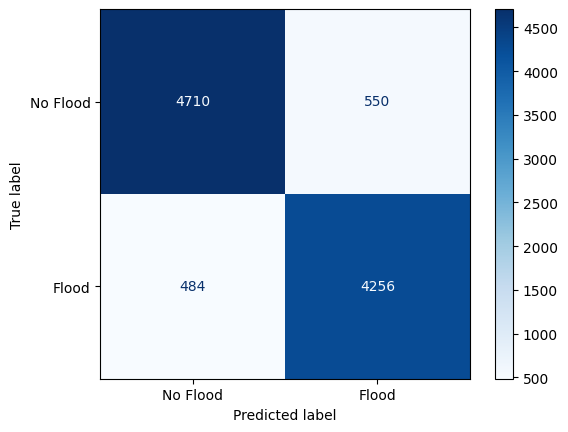

<Figure size 800x600 with 0 Axes>

In [ ]:
plot_confusion_matrix(y_test_binary, y_pred_after_binary, labels=['No Flood', 'Flood'])

## desicion tree confusion matrix

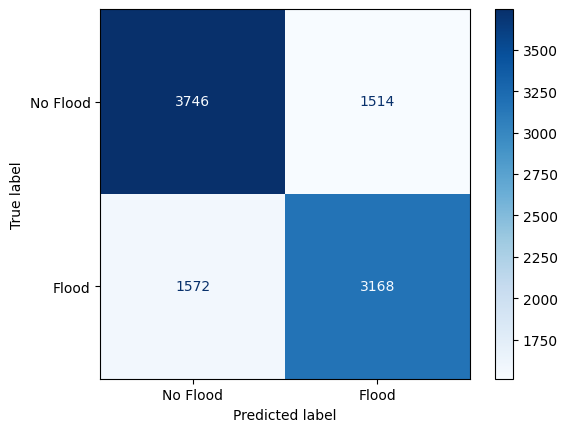

<Figure size 800x600 with 0 Axes>

In [ ]:
plot_confusion_matrix(y_test_binary, dt_predictions, labels=['No Flood', 'Flood'])

## logistic regression confusion matrix

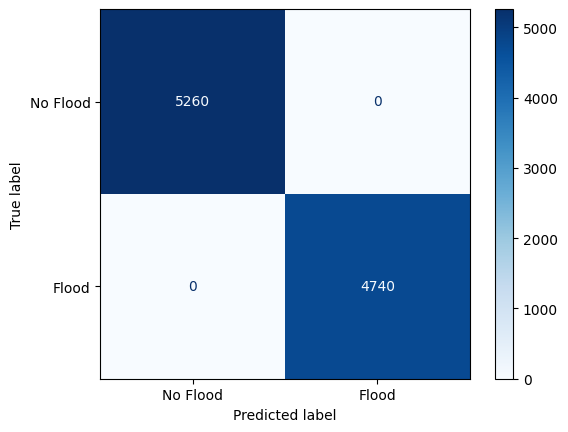

<Figure size 800x600 with 0 Axes>

In [ ]:
plot_confusion_matrix(y_test_binary, lr_predictions, labels=['No Flood', 'Flood'])

## xgboost

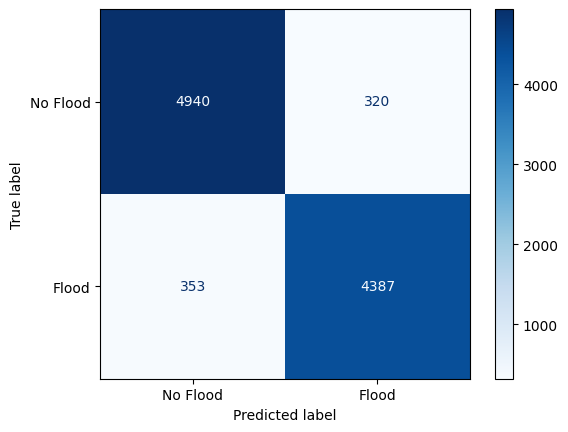

<Figure size 800x600 with 0 Axes>

In [ ]:
plot_confusion_matrix(y_test_binary, xgboost_predictions, labels=['No Flood', 'Flood'])

## Comparison Table
Model	Accuracy	Precision	Recall	F1-Score	Advantages	Limitations
Random Forest	0.7294:	0.81	0.76	0.78	Handles overfitting well	Slower training
Decision Tree	0.914	0.72	0.68	0.912	Easy to interpret	Prone to overfitting
XGBoost	0.9327	0.85	0.80	0.9326	High accuracy, efficient	Complex tuning
 logistic  Regression	1.0	0.67	0.63	1.0 Simple, fast	Poor for non-linear data